In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SRC = Path("..") / "src"
sys.path.insert(0, str(SRC))

import synthetic_cfd as sc
import pinn_inverse_viscosity as piv
from plot_utils import apply_plot_style, MU_SB, DEG_SB
from json_utils import json_convert, json_deconvert

apply_plot_style()

np.random.seed(0)

In [3]:
RESULTS_DIR = Path("..") / "results" / "gated_loss_balancing_demo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("..") / "data" / "processed"

RUNS_HISTORY_PATH = RESULTS_DIR / "runs_history.json"
FIELD_GRID_PATH = RESULTS_DIR / "field_grid.json"

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_ORDER = ["fnn_baseline", "fnn_adaptive", "modified_mlp_baseline", "modified_mlp_adaptive"]
RUN_LABELS = {
    "fnn_baseline": "FNN (baseline)",
    "fnn_adaptive": "FNN + adaptive weights",
    "modified_mlp_baseline": "Modified-MLP (gated)",
    "modified_mlp_adaptive": "Modified-MLP + adaptive weights",
}
RUN_CONFIGS = {
    "fnn_baseline": dict(architecture="fnn", adaptive_loss_weights=False),
    "fnn_adaptive": dict(architecture="fnn", adaptive_loss_weights=True),
    "modified_mlp_baseline": dict(architecture="modified_mlp", adaptive_loss_weights=False),
    "modified_mlp_adaptive": dict(architecture="modified_mlp", adaptive_loss_weights=True),
}
CHECKPOINT_PATHS = {name: RESULTS_DIR / f"{name}_checkpoint.pt" for name in RUN_ORDER}

RESUME_TRAINING = True

## Fake CFD: 2D Taylor-Green vortex

In [4]:
RHO = 1.0
MU_TRUE = 0.05
NOISE_STD = 0.0
T_RANGE = (0.0, 1.0)

dataset = sc.sample_synthetic_dataset(
    n_samples=3000,
    mu=MU_TRUE,
    rho=RHO,
    t_range=T_RANGE,
    noise_std=NOISE_STD,
    seed=0,
)
sc.save_dataset(dataset, DATA_DIR / "gated_loss_balancing_dataset.npz")
print({k: v.shape if hasattr(v, "shape") else v for k, v in dataset.items()})

{'X': (3000, 4), 'u': (3000, 1), 'v': (3000, 1), 'w': (3000, 1), 'p': (3000, 1), 'mu_true': 0.05, 'rho': 1.0}


## Train 4 runs: FNN vs. gated MLP, fixed vs. adaptive weights

In [5]:
ADAM_ITERATIONS = 15000
LBFGS_ITERATIONS = 15000
MU_INIT = 1.0

runs_result = {}
for name in RUN_ORDER:
    print(f"=== training run: {name} ===")
    result = piv.run_inverse_viscosity(
        dataset,
        rho=RHO,
        mu_init=MU_INIT,
        z_range=(0.0, 1.0),
        t_range=T_RANGE,
        num_domain=4000,
        adam_iterations=ADAM_ITERATIONS,
        adam_lr=1e-3,
        log_every=500,
        lbfgs_iterations=LBFGS_ITERATIONS,
        checkpoint_path=CHECKPOINT_PATHS[name],
        resume=RESUME_TRAINING,
        **RUN_CONFIGS[name],
    )
    runs_result[name] = result

with open(RUNS_HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "mu_true": MU_TRUE,
            "runs": {
                name: {
                    "history": r["history"],
                    "mu_recovered": r["mu_recovered"],
                    "architecture": r["architecture"],
                    "adaptive_loss_weights": RUN_CONFIGS[name]["adaptive_loss_weights"],
                }
                for name, r in runs_result.items()
            },
        },
        f, default=json_convert, ensure_ascii=False, indent=2,
    )

for name, r in runs_result.items():
    rel_err = abs(r["mu_recovered"] - MU_TRUE) / MU_TRUE
    print(f"{name:24s}  mu_recovered={r['mu_recovered']:.5f}  rel_error={rel_err:.2%}")

=== training run: fnn_baseline ===
Training on device: cuda
[adam] iter      0  loss=1.3850e+00  data=1.2186e+00  pde=1.6637e-01  mu=0.99900
[adam] iter    500  loss=9.3670e-02  data=6.9379e-02  pde=2.4290e-02  mu=0.44269
[adam] iter   1000  loss=1.5001e-02  data=9.7161e-03  pde=5.2850e-03  mu=0.09331
[adam] iter   1500  loss=6.5122e-03  data=3.6948e-03  pde=2.8174e-03  mu=0.04971
[adam] iter   2000  loss=3.6837e-03  data=1.8517e-03  pde=1.8321e-03  mu=0.03672
[adam] iter   2500  loss=2.4305e-03  data=1.1852e-03  pde=1.2453e-03  mu=0.03268
[adam] iter   3000  loss=1.8043e-03  data=8.6679e-04  pde=9.3750e-04  mu=0.03255
[adam] iter   3500  loss=1.1722e-03  data=5.2417e-04  pde=6.4800e-04  mu=0.03277
[adam] iter   4000  loss=7.7042e-04  data=3.0916e-04  pde=4.6126e-04  mu=0.03486
[adam] iter   4500  loss=5.9766e-04  data=2.2996e-04  pde=3.6771e-04  mu=0.03616
[adam] iter   5000  loss=4.7912e-04  data=1.7990e-04  pde=2.9922e-04  mu=0.03798
[adam] iter   5500  loss=4.5346e-04  data=1.7860e

### Loss comparison

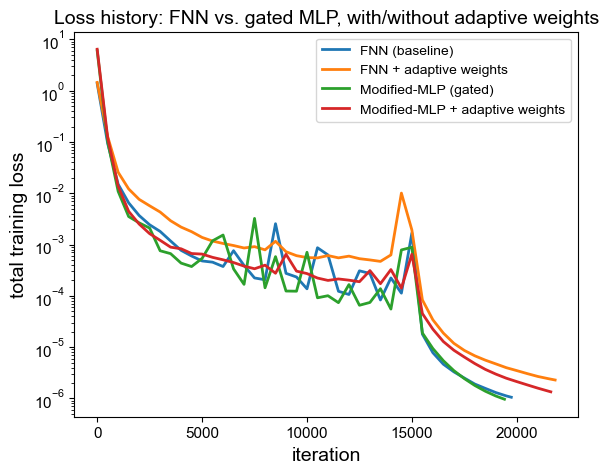

In [6]:
with open(RUNS_HISTORY_PATH, encoding="utf-8") as f:
    runs_data = json.load(f, object_hook=json_deconvert)
mu_true_for_plot = runs_data["mu_true"]
runs = runs_data["runs"]

fig, ax = plt.subplots(figsize=(6.5, 5))
for i, name in enumerate(RUN_ORDER):
    h = runs[name]["history"]
    ax.semilogy(h["iteration"], h["loss"], label=RUN_LABELS[name], color=f"C{i}")
ax.set_xlabel("iteration"); ax.set_ylabel("total training loss")
ax.set_title("Loss history: FNN vs. gated MLP, with/without adaptive weights")
ax.legend(fontsize=10)
fig.savefig(FIGURES_DIR / "loss_comparison.png")
plt.show()

### Viscosity convergence

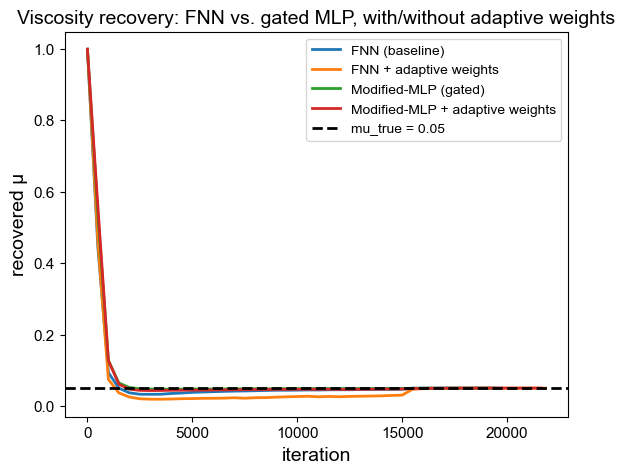

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for i, name in enumerate(RUN_ORDER):
    h = runs[name]["history"]
    ax.plot(h["iteration"], h["mu"], label=RUN_LABELS[name], color=f"C{i}")
ax.axhline(mu_true_for_plot, color="k", ls="--", label=f"mu_true = {mu_true_for_plot}")
ax.set_xlabel("iteration"); ax.set_ylabel(f"recovered {MU_SB}")
ax.set_title("Viscosity recovery: FNN vs. gated MLP, with/without adaptive weights")
ax.legend(fontsize=10)
fig.savefig(FIGURES_DIR / "mu_convergence_comparison.png")
plt.show()

### Adaptive loss-weight evolution

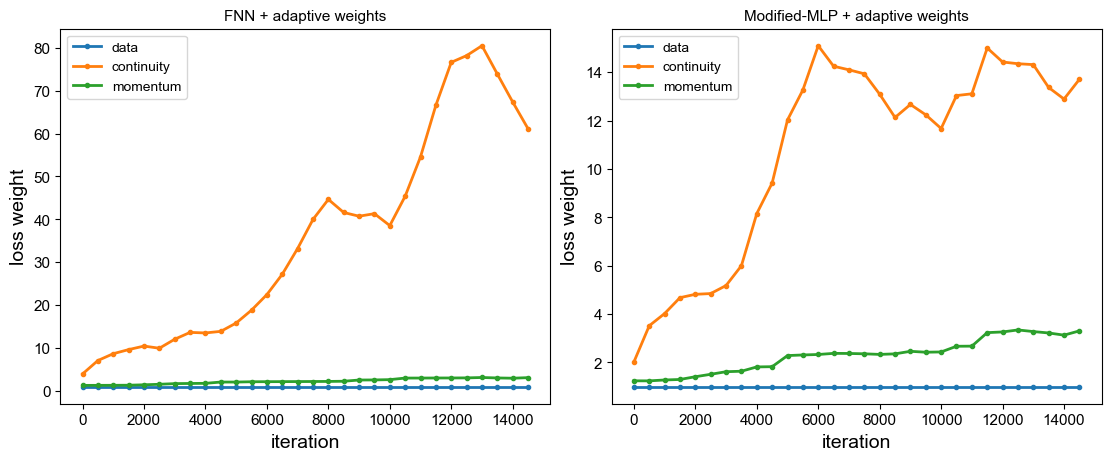

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, name in zip(axes, ["fnn_adaptive", "modified_mlp_adaptive"]):
    weight_history = runs[name]["history"]["loss_weights"]
    iters = [w["iteration"] for w in weight_history]
    for term in ["data", "continuity", "momentum"]:
        ax.plot(iters, [w[term] for w in weight_history], marker="o", ms=3, label=term)
    ax.set_xlabel("iteration"); ax.set_ylabel("loss weight")
    ax.set_title(RUN_LABELS[name], fontsize=11)
    ax.legend(fontsize=10)
fig.savefig(FIGURES_DIR / "loss_weight_evolution.png")
plt.show()

### Summary

run                            architecture   adaptive  mu_recovered  rel_error  final_loss 
fnn_baseline                   fnn            False     0.04996       0.09%      1.0549e-06 
fnn_adaptive                   fnn            True      0.04984       0.33%      2.2873e-06 
modified_mlp_baseline          modified_mlp   False     0.04990       0.20%      9.6528e-07 
modified_mlp_adaptive          modified_mlp   True      0.04996       0.07%      1.3451e-06 


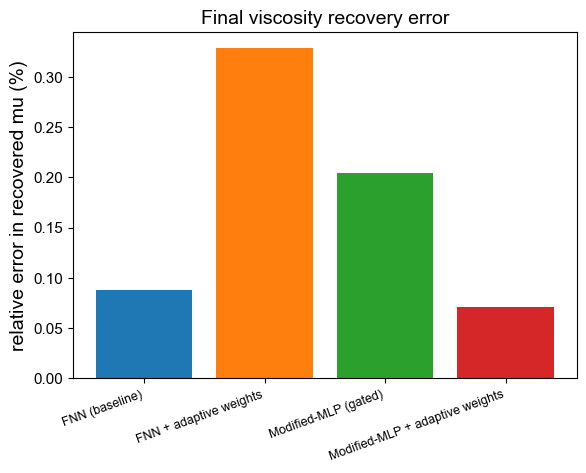

In [9]:
summary_rows = []
print(f"{'run':30s} {'architecture':14s} {'adaptive':9s} {'mu_recovered':13s} {'rel_error':10s} {'final_loss':11s}")
for name in RUN_ORDER:
    r = runs[name]
    h = r["history"]
    rel_err = abs(r["mu_recovered"] - mu_true_for_plot) / mu_true_for_plot
    final_loss = h["loss"][-1]
    summary_rows.append((name, r["architecture"], r["adaptive_loss_weights"], r["mu_recovered"], rel_err, final_loss))
    print(
        f"{name:30s} {r['architecture']:14s} {str(r['adaptive_loss_weights']):9s} "
        f"{r['mu_recovered']:<13.5f} {rel_err:<10.2%} {final_loss:<11.4e}"
    )

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(range(len(RUN_ORDER)), [row[4] * 100 for row in summary_rows], color=[f"C{i}" for i in range(len(RUN_ORDER))])
ax.set_xticks(range(len(RUN_ORDER)))
ax.set_xticklabels([RUN_LABELS[n] for n in RUN_ORDER], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("relative error in recovered mu (%)")
ax.set_title("Final viscosity recovery error")
fig.savefig(FIGURES_DIR / "summary_bar.png")
plt.show()

### Reconstruct

In [10]:
dataset_for_field = sc.load_dataset(DATA_DIR / "gated_loss_balancing_dataset.npz")
mu_true_for_field = float(dataset_for_field["mu_true"])
rho_for_field = float(dataset_for_field["rho"])

T_SNAP = 0.5
x_lin = np.linspace(0, 2 * np.pi, 60)
y_lin = np.linspace(0, 2 * np.pi, 60)
xg_field, yg_field = np.meshgrid(x_lin, y_lin)
u_exact, _, _, _ = sc.taylor_green_fields(
    xg_field, yg_field, np.zeros_like(xg_field), np.full_like(xg_field, T_SNAP), mu_true_for_field, rho_for_field
)

with open(FIELD_GRID_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {"t_snap": T_SNAP, "x_lin": x_lin, "y_lin": y_lin, "u_exact": u_exact},
        f, default=json_convert, ensure_ascii=False, indent=2,
    )
print(f"Field grid saved to: {FIELD_GRID_PATH}")

Field grid saved to: ..\results\gated_loss_balancing_demo\field_grid.json


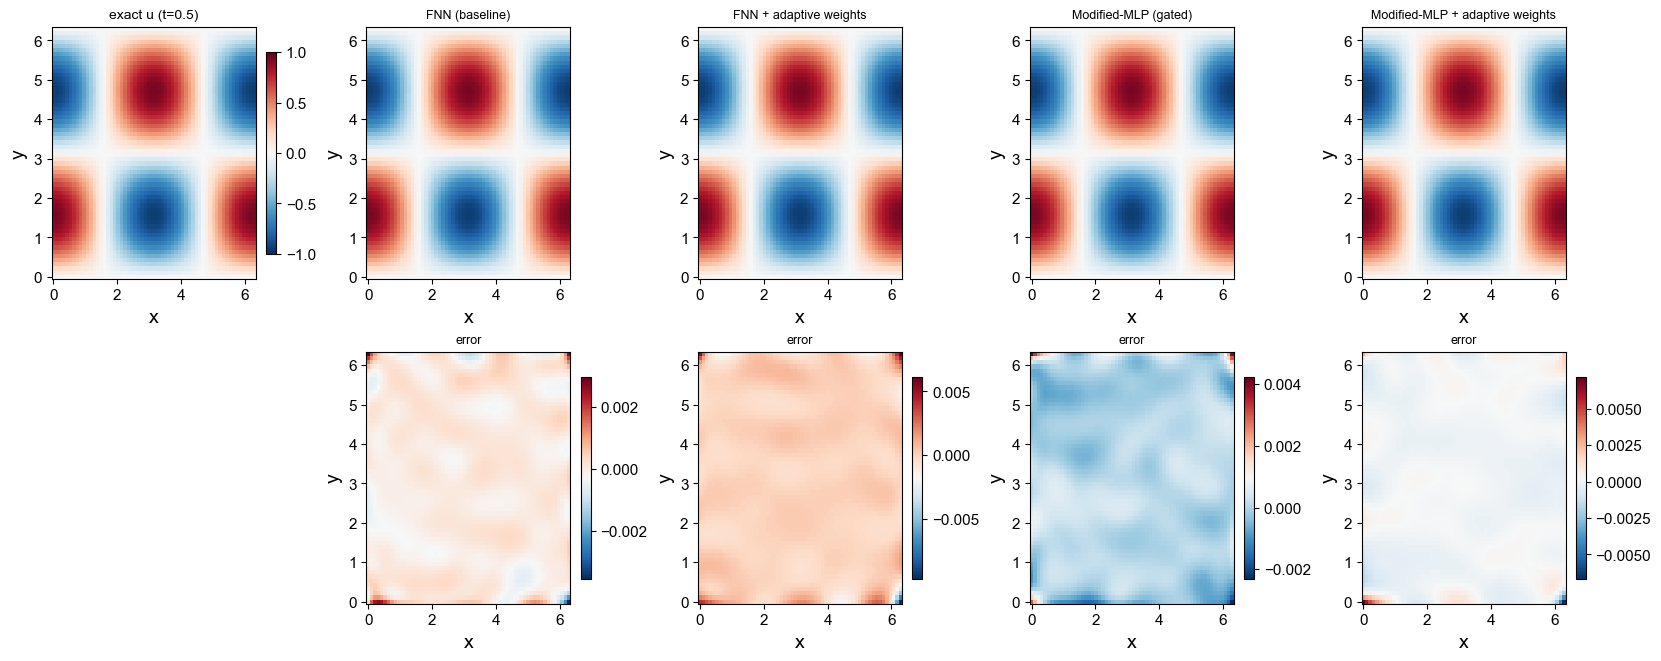

In [11]:
with open(FIELD_GRID_PATH, encoding="utf-8") as f:
    field_data = json.load(f, object_hook=json_deconvert)
t_snap = field_data["t_snap"]
xg, yg = np.meshgrid(field_data["x_lin"], field_data["y_lin"])
u_exact = field_data["u_exact"]
grid_X = np.column_stack([xg.ravel(), yg.ravel(), np.zeros(xg.size), np.full(xg.size, t_snap)])

fig, axes = plt.subplots(2, len(RUN_ORDER) + 1, figsize=(3.3 * (len(RUN_ORDER) + 1), 6.5), constrained_layout=True)

im0 = axes[0, 0].pcolormesh(xg, yg, u_exact, shading="auto", cmap="RdBu_r", vmin=-1, vmax=1)
axes[0, 0].set_title(f"exact u (t={t_snap})", fontsize=10)
fig.colorbar(im0, ax=axes[0, 0], shrink=0.8)
axes[1, 0].axis("off")

for col, name in enumerate(RUN_ORDER, start=1):
    model, _ = piv.load_model(CHECKPOINT_PATHS[name])
    u_pred = model.predict(grid_X)[:, 0].reshape(xg.shape)

    axes[0, col].pcolormesh(xg, yg, u_pred, shading="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0, col].set_title(RUN_LABELS[name], fontsize=9)

    im_err = axes[1, col].pcolormesh(xg, yg, u_pred - u_exact, shading="auto", cmap="RdBu_r")
    fig.colorbar(im_err, ax=axes[1, col], shrink=0.8)
    axes[1, col].set_title("error", fontsize=9)

for ax in axes.ravel():
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.savefig(FIGURES_DIR / "field_reconstruction_comparison.png")
plt.show()